In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Load Data
orders_df = pd.read_csv("orders_raw.csv")
products_df = pd.read_csv("products.csv")

# 2. Drop Duplicates
initial_rows = len(orders_df)
orders_df = orders_df.drop_duplicates(subset=['order_id'], keep='first')
print(f"Duplicates removed. Remaining rows: {len(orders_df)} (Expected: 500)")

# 3. Clean Casing & Whitespace
orders_df['city'] = orders_df['city'].astype(str).str.strip().str.title()
orders_df['category'] = orders_df['category'].astype(str).str.strip().str.title()
print("Distinct Cities after cleaning:", orders_df['city'].unique())
print("Distinct Categories after cleaning:", orders_df['category'].unique())


Duplicates removed. Remaining rows: 500 (Expected: 500)
Distinct Cities after cleaning: ['Pune' 'Bengaluru' 'Hyderabad' 'Mumbai']
Distinct Categories after cleaning: ['Snacks & Beverages' 'Household Essentials' 'Bakery' 'Personal Care'
 'Fruits & Vegetables' 'Dairy & Eggs']


In [2]:
# 5. Outlier Detection and Capping via IQR
delivered_valid = orders_df[(orders_df['status'] == 'Delivered') & (orders_df['amount_inr'].notna())]
Q1 = delivered_valid['amount_inr'].quantile(0.25)
Q3 = delivered_valid['amount_inr'].quantile(0.75)
IQR = Q3 - Q1
upper_fence = Q3 + (1.5 * IQR)

# Cap values using clip
orders_df['amount_inr'] = orders_df['amount_inr'].clip(upper=upper_fence)
print(f"IQR Capping Complete. Upper Fence: {upper_fence}")

# 6. Parse Dates & Create Derived Columns
orders_df['order_date'] = pd.to_datetime(orders_df['order_date'])
orders_df['month_name'] = orders_df['order_date'].dt.month_name()
orders_df['revenue_per_unit'] = orders_df['amount_inr'] / orders_df['quantity']


IQR Capping Complete. Upper Fence: 552.5



--- Top Category by Revenue ---
category
Household Essentials    20910.0
Name: amount_inr, dtype: float64

--- Top Supplier by Revenue ---
supplier
HomeEssentials Traders    20910.0
Name: amount_inr, dtype: float64


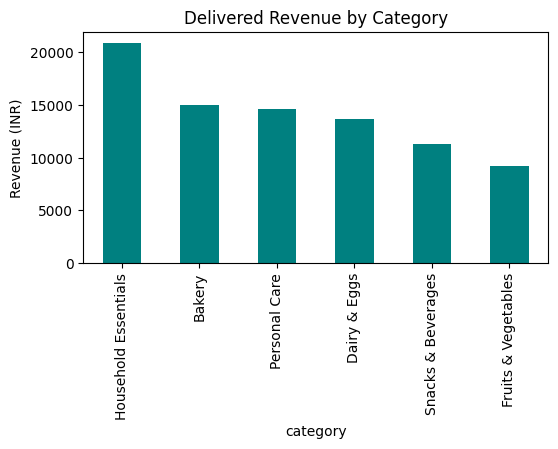

In [3]:
# 7. Group, Merge and Cross-Validate
delivered_df = orders_df[orders_df['status'] == 'Delivered']
category_revenue = delivered_df.groupby('category')['amount_inr'].sum().sort_values(ascending=False)
print("\n--- Top Category by Revenue ---")
print(category_revenue.head(1))

merged_df = pd.merge(orders_df, products_df, on='product_id', suffixes=('', '_prod'))
delivered_merged = merged_df[merged_df['status'] == 'Delivered']
supplier_revenue = delivered_merged.groupby('supplier')['amount_inr'].sum().sort_values(ascending=False)
print("\n--- Top Supplier by Revenue ---")
print(supplier_revenue.head(1))

# 8. Visualizations
plt.figure(figsize=(6, 3))
category_revenue.plot(kind='bar', color='teal')
plt.title('Delivered Revenue by Category')
plt.ylabel('Revenue (INR)')
plt.show()
